<a href="https://colab.research.google.com/github/Bonesha-5/PCA_Formative_Peer_Pair_3/blob/main/PCA_Formative_1%5BPeer_Pair_3%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Dataset: Education & Literacy in African Countries

**Source:** World Bank, World Development Indicators (DataBank)
**Coverage:** 54 African countries, 2015–2019 (270 rows: one per country per year)

**Why this dataset is impactful:** education and literacy are key drivers of development in Africa. The indicators cover access to school, completion, learning outcomes, teachers, spending and gender equality.

**How it meets the requirements:**
- **11 numeric indicators:** adult and youth literacy, primary/secondary/tertiary enrollment, primary completion, children out of school, pupil-teacher ratio, trained teachers, education spending (% of GDP), and the primary gender parity index
- **Non-numeric columns:** Time Code, Country Name, Country Code
- **Missing values:** 1,386 of 2,970 values (46.7%) are missing, shown as `..` in the file

**Libraries:** NumPy for all computations and Matplotlib for the plots only.

### Step 1: Load and Standardize the Data
Before applying PCA, we must standardize the dataset. Standardization ensures that all features have a mean of 0 and a standard deviation of 1, which is essential for PCA.
Fill in the code to standardize the dataset.

STRICTLY - Write code that implements standardization based on the image below

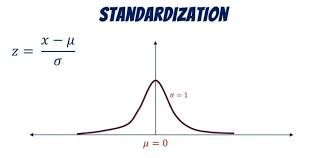


In [116]:
#Importing libraries
import numpy as np
import matplotlib.pyplot as plt

### Loading the Data
The CSV is read line by line and split with a custom parser, because some column names contain commas inside quotation marks. Empty rows and the World Bank notes at the bottom of the file are skipped, since they are not data. Everything is kept as text at first, because the file mixes words and numbers.

In [117]:
file_path = 'africa_education_2015_2019.csv'

# Read all lines from the CSV file
with open(file_path, 'r', encoding='utf-8') as file:
    lines = file.readlines()

# Separate the header from the data
header_line = lines[0].strip()

data_lines = []

for line in lines[1:]:
    line = line.strip()

    # Ignore empty rows and database information at the bottom
    if line == "" or line.startswith(","):
        continue

    if line.startswith("Data from database"):
        continue

    if line.startswith("Last Updated"):
        continue

    data_lines.append(line)


# Function to correctly separate CSV values,
# including values that contain commas inside quotation marks
def parse_csv_line(line):
    fields = []
    current = ""
    inside_quotes = False

    for character in line:
        if character == '"':
            inside_quotes = not inside_quotes

        elif character == ',' and not inside_quotes:
            fields.append(current)
            current = ""

        else:
            current += character

    fields.append(current)

    return fields


# Parse the header and data
header = np.array(parse_csv_line(header_line), dtype=str)

data = np.array(
    [parse_csv_line(line) for line in data_lines],
    dtype=str
)

print("Data shape:", data.shape)
print("Number of columns:", len(header))
print("First row:")
print(data[0])

Data shape: (270, 15)
Number of columns: 15
First row:
['2015' 'YR2015' 'Algeria' 'DZA' '..' '..' '109.584787441309' '..'
 '38.2444735695552' '98.4612319244171' '0.410926282137215' '23.83613'
 '100' '6.17633014564047' '0.952300012111664']


In [118]:
print("Column names:")

for i in range(len(header)):
    print(i, ":", header[i])

Column names:
0 : Time
1 : Time Code
2 : Country Name
3 : Country Code
4 : Literacy rate, adult total (% of people ages 15 and above) [SE.ADT.LITR.ZS]
5 : Literacy rate, youth total (% of people ages 15-24) [SE.ADT.1524.LT.ZS]
6 : School enrollment, primary (% gross) [SE.PRM.ENRR]
7 : School enrollment, secondary (% gross) [SE.SEC.ENRR]
8 : School enrollment, tertiary (% gross) [SE.TER.ENRR]
9 : Primary completion rate, total (% of relevant age group) [SE.PRM.CMPT.ZS]
10 : Children out of school (% of primary school age) [SE.PRM.UNER.ZS]
11 : Pupil-teacher ratio, primary [SE.PRM.ENRL.TC.ZS]
12 : Trained teachers in primary education (% of total teachers) [SE.PRM.TCAQ.ZS]
13 : Government expenditure on education, total (% of GDP) [SE.XPD.TOTL.GD.ZS]
14 : School enrollment, primary (gross), gender parity index (GPI) [SE.ENR.PRIM.FM.ZS]


In [119]:
print("Missing values represented by '..':")

for i in range(len(header)):
    count = np.sum(data[:, i] == "..")
    print(header[i], ":", count)

Missing values represented by '..':
Time : 0
Time Code : 0
Country Name : 0
Country Code : 0
Literacy rate, adult total (% of people ages 15 and above) [SE.ADT.LITR.ZS] : 204
Literacy rate, youth total (% of people ages 15-24) [SE.ADT.1524.LT.ZS] : 203
School enrollment, primary (% gross) [SE.PRM.ENRR] : 80
School enrollment, secondary (% gross) [SE.SEC.ENRR] : 134
School enrollment, tertiary (% gross) [SE.TER.ENRR] : 134
Primary completion rate, total (% of relevant age group) [SE.PRM.CMPT.ZS] : 118
Children out of school (% of primary school age) [SE.PRM.UNER.ZS] : 120
Pupil-teacher ratio, primary [SE.PRM.ENRL.TC.ZS] : 137
Trained teachers in primary education (% of total teachers) [SE.PRM.TCAQ.ZS] : 144
Government expenditure on education, total (% of GDP) [SE.XPD.TOTL.GD.ZS] : 56
School enrollment, primary (gross), gender parity index (GPI) [SE.ENR.PRIM.FM.ZS] : 56


### Separating Labels from Numeric Features
Columns 0–3 (Time, Time Code, Country Name, Country Code) describe each row, so they are kept as labels and not used in PCA. Columns 4–14 are the 11 numeric indicators. The `..` markers are converted to `NaN` so NumPy can recognise them as missing.

In [120]:
indicator_names = header[4:]

print("Number of indicators:", len(indicator_names))

for i, name in enumerate(indicator_names):
    print(i, ":", name)

Number of indicators: 11
0 : Literacy rate, adult total (% of people ages 15 and above) [SE.ADT.LITR.ZS]
1 : Literacy rate, youth total (% of people ages 15-24) [SE.ADT.1524.LT.ZS]
2 : School enrollment, primary (% gross) [SE.PRM.ENRR]
3 : School enrollment, secondary (% gross) [SE.SEC.ENRR]
4 : School enrollment, tertiary (% gross) [SE.TER.ENRR]
5 : Primary completion rate, total (% of relevant age group) [SE.PRM.CMPT.ZS]
6 : Children out of school (% of primary school age) [SE.PRM.UNER.ZS]
7 : Pupil-teacher ratio, primary [SE.PRM.ENRL.TC.ZS]
8 : Trained teachers in primary education (% of total teachers) [SE.PRM.TCAQ.ZS]
9 : Government expenditure on education, total (% of GDP) [SE.XPD.TOTL.GD.ZS]
10 : School enrollment, primary (gross), gender parity index (GPI) [SE.ENR.PRIM.FM.ZS]


In [121]:
years = data[:, 0]
countries = data[:, 2]

print("Years:")
print(years[:10])

print("\nCountries:")
print(countries[:10])

Years:
['2015' '2015' '2015' '2015' '2015' '2015' '2015' '2015' '2015' '2015']

Countries:
['Algeria' 'Angola' 'Botswana' 'Burkina Faso' 'Burundi' 'Cabo Verde'
 'Cameroon' 'Central African Republic' 'Chad' 'Comoros']


### Step 2: Handle Missing Values and Encode Non-Numeric Data

**Missing values:**
- In this dataset, a missing value means the indicator was **not measured that year**, not that the value is zero. For example, literacy surveys are only done every few years.
- Deleting incomplete rows is not an option: only **11 of 270 rows** have no missing values.
- We therefore impute in two steps:
  1. Fill each gap with the **country's own average** from the years it was measured.
  2. If a country never reported an indicator, fill with the **column median**, which is less affected by extreme values than the mean.

**Non-numeric data:** Time Code and Country Code repeat the same information as Time and Country Name, so they are not used. A **Region** column is created for each country and **one-hot encoded**, and it is used to colour the plots.

In [122]:
indicator_raw = data[:, 4:]

# Create a mask for both types of missing values
missing_mask = (
    (indicator_raw == "..") |
    (indicator_raw == "")
)

# Create an empty numerical array
indicator_data = np.empty(
    indicator_raw.shape,
    dtype=float
)

# Put NaN wherever data is missing
indicator_data[missing_mask] = np.nan

# Convert all remaining values to numbers
indicator_data[~missing_mask] = (
    indicator_raw[~missing_mask]
    .astype(float)
)

print("Indicator data shape:", indicator_data.shape)

print("\nFirst 5 rows:")
print(indicator_data[:5])

print("\nTotal missing values:")
print(np.sum(np.isnan(indicator_data)))

Indicator data shape: (270, 11)

First 5 rows:
[[         nan          nan 109.58478744          nan  38.24447357
   98.46123192   0.41092628  23.83613    100.           6.17633015
    0.95230001]
 [ 66.23999786  75.66000366 120.58027649          nan   8.78320868
           nan          nan  50.02951             nan   3.4868958
    0.87413001]
 [         nan          nan 101.62335205          nan  26.86929255
           nan          nan  23.71279             nan   8.39457942
    0.97776002]
 [         nan          nan  85.14848277  32.89313436   4.90356866
   60.34484192  32.49785069  42.17715     85.42001028   3.67008996
    0.97443998]
 [         nan          nan 116.22812808  43.93519298   5.25856538
   60.09523066  11.09726631  43.22109    100.           6.3713398
    1.02955997]]

Total missing values:
1386


In [123]:
complete_rows = np.sum(
    ~np.isnan(indicator_data).any(axis=1)
)

print("Rows with no missing values:", complete_rows)

Rows with no missing values: 11


In [124]:
unique_countries = np.unique(countries)

print("Number of countries:", len(unique_countries))
print(unique_countries)

for country in unique_countries:

    country_rows = countries == country

    counts = np.sum(
        ~np.isnan(indicator_data[country_rows]),
        axis=0
    )

    print("\n", country)
    print(counts)

Number of countries: 54
['Algeria' 'Angola' 'Benin' 'Botswana' 'Burkina Faso' 'Burundi'
 'Cabo Verde' 'Cameroon' 'Central African Republic' 'Chad' 'Comoros'
 'Congo, Dem. Rep.' 'Congo, Rep.' "Cote d'Ivoire" 'Djibouti'
 'Egypt, Arab Rep.' 'Equatorial Guinea' 'Eritrea' 'Eswatini' 'Ethiopia'
 'Gabon' 'Gambia, The' 'Ghana' 'Guinea' 'Guinea-Bissau' 'Kenya' 'Lesotho'
 'Liberia' 'Libya' 'Madagascar' 'Malawi' 'Mali' 'Mauritania' 'Mauritius'
 'Morocco' 'Mozambique' 'Namibia' 'Niger' 'Nigeria' 'Rwanda'
 'Sao Tome and Principe' 'Senegal' 'Seychelles' 'Sierra Leone'
 'Somalia, Fed. Rep.' 'South Africa' 'South Sudan' 'Sudan' 'Tanzania'
 'Togo' 'Tunisia' 'Uganda' 'Zambia' 'Zimbabwe']

 Algeria
[0 0 5 0 5 5 5 4 5 5 5]

 Angola
[1 1 1 1 2 0 0 1 0 5 4]

 Benin
[2 2 5 2 5 3 4 4 5 5 5]

 Botswana
[0 0 1 0 4 0 0 1 0 5 2]

 Burkina Faso
[2 2 5 5 5 5 5 4 5 4 5]

 Burundi
[2 2 5 5 4 5 5 4 5 5 5]

 Cabo Verde
[1 1 5 5 4 5 5 4 4 5 5]

 Cameroon
[1 1 5 2 5 5 4 4 1 5 5]

 Central African Republic
[1 1 1 2 0 1 0 

In [125]:
imputed_data = indicator_data.copy()

for country in unique_countries:

    country_rows = countries == country

    for j in range(imputed_data.shape[1]):

        values = imputed_data[country_rows, j].copy()

        if np.isnan(values).any() and not np.isnan(values).all():

            country_mean = np.nanmean(values)
            values[np.isnan(values)] = country_mean
            imputed_data[country_rows, j] = values

print("Missing values after country-average imputation:",
      np.sum(np.isnan(imputed_data)))

Missing values after country-average imputation: 615


In [126]:
for j in range(imputed_data.shape[1]):

    column_median = np.nanmedian(imputed_data[:, j])

    missing = np.isnan(imputed_data[:, j])

    imputed_data[missing, j] = column_median


print("Remaining missing values:",
      np.sum(np.isnan(imputed_data)))

Remaining missing values: 0


### Encoding the Region
Each country is assigned to one of five African regions (North, West, Central, East, Southern). The region is then **one-hot encoded**: one 0/1 column per region. One-hot encoding is used instead of numbers like 1, 2, 3, because numbers would wrongly suggest that one region is "bigger" than another.

In [127]:
def get_region(country):

    east_africa = [
        "Burundi", "Comoros", "Djibouti", "Eritrea",
        "Ethiopia", "Kenya", "Madagascar", "Malawi",
        "Mauritius", "Mozambique", "Rwanda", "Seychelles",
        "Somalia, Fed. Rep.", "South Sudan", "Tanzania", "Uganda",
        "Zambia", "Zimbabwe"
    ]

    west_africa = [
        "Benin", "Burkina Faso", "Cabo Verde", "Cote d'Ivoire",
        "Gambia, The", "Ghana", "Guinea", "Guinea-Bissau",
        "Liberia", "Mali", "Mauritania", "Niger",
        "Nigeria", "Senegal", "Sierra Leone", "Togo"
    ]

    central_africa = [
        "Angola", "Cameroon", "Central African Republic",
        "Chad", "Congo, Dem. Rep.", "Congo, Rep.",
        "Equatorial Guinea", "Gabon", "Sao Tome and Principe"   # FIXED
    ]

    north_africa = [
        "Algeria", "Egypt, Arab Rep.", "Libya",
        "Morocco", "Sudan", "Tunisia"
    ]

    southern_africa = [
        "Botswana", "Eswatini", "Lesotho",
        "Namibia", "South Africa"
    ]

    if country in east_africa:
        return "East Africa"

    elif country in west_africa:
        return "West Africa"

    elif country in central_africa:
        return "Central Africa"

    elif country in north_africa:
        return "North Africa"

    elif country in southern_africa:
        return "Southern Africa"

    else:
        return "Other"


regions = np.array([
    get_region(country)
    for country in countries
])

print("First 20 regions:")
print(regions[:20])

First 20 regions:
['North Africa' 'Central Africa' 'Southern Africa' 'West Africa'
 'East Africa' 'West Africa' 'Central Africa' 'Central Africa'
 'Central Africa' 'East Africa' 'Central Africa' 'Central Africa'
 'West Africa' 'East Africa' 'North Africa' 'Central Africa' 'East Africa'
 'Southern Africa' 'East Africa' 'Central Africa']


In [128]:
unique_regions = np.unique(regions)

region_encoded = np.zeros(
    (len(regions), len(unique_regions))
)

for i in range(len(regions)):

    for j in range(len(unique_regions)):

        if regions[i] == unique_regions[j]:

            region_encoded[i, j] = 1


print("Regions:")
print(unique_regions)

print("\nOne-hot encoded regions:")
print(region_encoded[:10])

print("\nShape:")
print(region_encoded.shape)

Regions:
['Central Africa' 'East Africa' 'North Africa' 'Southern Africa'
 'West Africa']

One-hot encoded regions:
[[0. 0. 1. 0. 0.]
 [1. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]
 [0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]]

Shape:
(270, 5)


### Standardization
The data is standardized using the formula $z = \frac{x - \mu}{\sigma}$, so every indicator has a mean of 0 and a standard deviation of 1. This is needed because the indicators are on very different scales. For example, enrollment can be above 100%, while education spending is only a few percent of GDP. Without standardizing, the indicators with bigger numbers would dominate PCA. Standardization is done **after** cleaning, because the mean and standard deviation can't be calculated with missing values.

In [129]:
means = np.mean(imputed_data, axis=0)

print("Means:")
print(means)

Means:
[64.7374174  77.71174319 99.82900948 52.74393267 13.69972997 72.6615024
 17.27411071 36.77952861 82.41116753  3.83388828  0.96022921]


In [130]:
stds = np.std(imputed_data, axis=0)

print("Standard deviations:")
print(stds)

Standard deviations:
[15.52430111 13.00308441 18.80774773 21.11268819  9.70377081 18.15510388
 13.98357076 12.23870286 17.88607473  1.75735824  0.07535546]


In [131]:
standardized_data = (
    imputed_data - means
) / stds

print("Standardized data:")
print(standardized_data[:5])

Standardized data:
[[ 0.07907491  0.15905885  0.51871059 -0.24836625  2.52940265  1.42107309
  -1.20592835 -1.05757928  0.98338136  1.33293362 -0.10522396]
 [ 0.09678893 -0.15778868  1.1033361   0.0792351  -0.5066609  -0.18250857
  -0.17493191  1.08262955  0.22915983 -0.19745119 -1.14257414]
 [ 0.07907491  0.15905885  0.09540444 -0.24836625  1.35715928 -0.18250857
  -0.17493191 -1.06765715  0.22915983  2.59519718  0.23264146]
 [-1.9474254  -1.90352868 -0.7805574  -0.94023073 -0.90646837 -0.67841311
   1.08868759  0.44102888  0.16822264 -0.09320713  0.1885831 ]
 [ 0.14799909  0.65970945  0.87193421 -0.41722492 -0.86988499 -0.69216193
  -0.44172154  0.52632713  0.98338136  1.44390112  0.92004954]]


### Step 3: Calculate the Covariance Matrix
The covariance matrix helps us understand how the features are related to each other. It is a key component in PCA.

In [132]:
cov_matrix = np.cov(
    standardized_data,
    rowvar=False
)

print("Covariance matrix shape:")
print(cov_matrix.shape)

print("\nCovariance matrix:")
print(cov_matrix)

Covariance matrix shape:
(11, 11)

Covariance matrix:
[[ 1.00371747  0.92380808  0.30734284  0.54244678  0.33854306  0.50175976
  -0.34600175 -0.36240939  0.10522471  0.33250362  0.33313141]
 [ 0.92380808  1.00371747  0.34734004  0.54970203  0.31942308  0.53268814
  -0.35617113 -0.42310042  0.08821233  0.34873165  0.41978502]
 [ 0.30734284  0.34734004  1.00371747  0.32414975  0.11824784  0.45720295
  -0.75460069  0.1007551   0.09632889  0.23477319  0.24159589]
 [ 0.54244678  0.54970203  0.32414975  1.00371747  0.6196375   0.75313657
  -0.46584385 -0.64268757  0.08812047  0.41686806  0.33127656]
 [ 0.33854306  0.31942308  0.11824784  0.6196375   1.00371747  0.61003332
  -0.37074741 -0.61131569  0.20402383  0.33837033  0.15767588]
 [ 0.50175976  0.53268814  0.45720295  0.75313657  0.61003332  1.00371747
  -0.50683255 -0.55327034  0.21312189  0.35252045  0.29026332]
 [-0.34600175 -0.35617113 -0.75460069 -0.46584385 -0.37074741 -0.50683255
   1.00371747  0.11124931 -0.15255739 -0.28696722 

In a paragraph that has a maximum if 5 Lines, Explain why we need to compute a covariance matrix, provide atleast 2 reasons.

We compute the covariance matrix to measure how the education indicators vary in relation to one another. It shows whether indicators tend to increase or decrease together. The covariance matrix is important for PCA because its eigenvalues and eigenvectors identify the directions of maximum variance in the dataset.


### Step 4: Perform Eigendecomposition
Eigendecomposition of the covariance matrix will give us the eigenvalues and eigenvectors, which are essential for PCA.

In [133]:
# Step 4: Perform Eigendecomposition
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
print("Eigenvalues before sorting:", np.round(eigenvalues, 4))
print("Eigenvectors shape:", eigenvectors.shape)

Eigenvalues before sorting: [0.0677 0.1586 0.1932 0.2484 0.3877 0.7426 0.7873 0.967  1.1762 1.5472
 4.7648]
Eigenvectors shape: (11, 11)


### Step 5: Sort Principal Components
The eigenvalues are sorted from largest to smallest, and the eigenvectors are rearranged in the same order, so PC1 is always the component that explains the most variance. The explained variance of each component is its eigenvalue divided by the sum of all eigenvalues. The signs of the eigenvectors are flipped where needed so the largest loading is positive. This doesn't change the components, and it makes them easier to read.

<a url ='https://www.youtube.com/watch?v=vaF-1xUEXsA&t=17s'>How Is Explained Variance Used In PCA?'<a/>

In [134]:
# Step 5: Sort Principal Components
sorted_indices = np.argsort(eigenvalues)[::-1]
sorted_eigenvalues = eigenvalues[sorted_indices]
sorted_eigenvectors = eigenvectors[:, sorted_indices]
print("Sorted eigenvalues:", np.round(sorted_eigenvalues, 4))

Sorted eigenvalues: [4.7648 1.5472 1.1762 0.967  0.7873 0.7426 0.3877 0.2484 0.1932 0.1586
 0.0677]


In [135]:
#Flip signs so the largest loading of each component is positive
sorted_eigenvectors = sorted_eigenvectors * np.sign(sorted_eigenvectors[np.abs(sorted_eigenvectors).argmax(axis=0), range(sorted_eigenvectors.shape[1])])
print("PC1 loadings:", np.round(sorted_eigenvectors[:, 0], 3))

PC1 loadings: [ 0.344  0.357  0.236  0.389  0.31   0.384 -0.296 -0.298  0.092  0.252
  0.235]


In [136]:
# Explained variance of each component (%)
explained_variance = sorted_eigenvalues / np.sum(sorted_eigenvalues) * 100
print("Explained variance (%):", np.round(explained_variance, 2))

Explained variance (%): [43.16 14.01 10.65  8.76  7.13  6.73  3.51  2.25  1.75  1.44  0.61]


In [137]:
# Cumulative explained variance (%)
cumulative_variance = np.cumsum(explained_variance)
print("Cumulative explained variance (%):", np.round(cumulative_variance, 2))

Cumulative explained variance (%): [ 43.16  57.17  67.82  76.58  83.71  90.44  93.95  96.2   97.95  99.39
 100.  ]


### Task 2: Dynamically Select the Number of Principal Components
Instead of choosing the number of components by hand, it is selected automatically as the **smallest number of components whose cumulative explained variance reaches the threshold (90%)**. If the threshold is changed, the number of components updates automatically.

In [138]:
# Select the number of components that reaches the variance threshold
variance_threshold = 90
num_components = int(np.argmax(cumulative_variance >= variance_threshold) + 1)
print(f"Selected variance threshold: {variance_threshold}%")
print("Number of principal components selected:", num_components)
print(f"Variance retained: {cumulative_variance[num_components - 1]:.2f}%")

Selected variance threshold: 90%
Number of principal components selected: 6
Variance retained: 90.44%


In [139]:
# Strongest indicators contributing to PC1 and PC2
short_names = [name.split(" [")[0] for name in indicator_names]
for pc in range(2):
    loadings = sorted_eigenvectors[:, pc]
    print(f"\nTop contributing indicators for PC{pc + 1}:")
    for i in np.argsort(np.abs(loadings))[::-1][:5]:
        print(f"  {short_names[i]}: loading = {loadings[i]:.4f}")


Top contributing indicators for PC1:
  School enrollment, secondary (% gross): loading = 0.3886
  Primary completion rate, total (% of relevant age group): loading = 0.3840
  Literacy rate, youth total (% of people ages 15-24): loading = 0.3571
  Literacy rate, adult total (% of people ages 15 and above): loading = 0.3439
  School enrollment, tertiary (% gross): loading = 0.3102

Top contributing indicators for PC2:
  School enrollment, primary (% gross): loading = 0.6239
  Pupil-teacher ratio, primary: loading = 0.5198
  Children out of school (% of primary school age): loading = -0.4768
  School enrollment, tertiary (% gross): loading = -0.2636
  Trained teachers in primary education (% of total teachers): loading = 0.1432


### Step 6: Project Data onto Principal Components
The standardized data is multiplied by the selected eigenvectors. Each new column is a principal component score: a combination of all 11 indicators.

In [140]:
# Step 6: Project Data onto Principal Components
reduced_data = standardized_data @ sorted_eigenvectors[:, :num_components]
print("Original standardized data shape:", standardized_data.shape)
print("Reduced data shape:", reduced_data.shape)

Original standardized data shape: (270, 11)
Reduced data shape: (270, 6)


### Step 7: Output the Reduced Data
Finally, display the reduced data obtained by projecting the original dataset onto the selected principal components.

In [141]:
# Step 7: Output the Reduced Data
print(f'Reduced Data Shape: {reduced_data.shape}')  # Display reduced data shape
reduced_data[:5]  # Display the first few rows of reduced data

Reduced Data Shape: (270, 6)


array([[ 2.51456682, -0.22198495,  2.11743972, -0.17005522,  0.09328507,
         0.35970398],
       [-0.5279669 ,  1.49254964,  0.34009016,  0.3258467 , -1.02716778,
         0.06747431],
       [ 1.4618168 , -0.82610782,  0.83602496,  0.10025531,  0.55262321,
         2.16507952],
       [-2.85787256, -0.39817671,  0.79857463, -0.58279868,  1.28542656,
         0.41763897],
       [ 0.43955231,  1.40597926, -0.40262442,  1.02380882,  1.27200538,
         1.34908532]])

### Step 8: Visualize Before and After PCA
Now, let's plot the original data and the data after PCA to compare the reduction in dimensions visually.

The first plot shows two original indicators (secondary enrollment and pupil-teacher ratio) before PCA. The second plot shows the same 270 observations on PC1 and PC2 after PCA. Points are coloured by region in both plots.

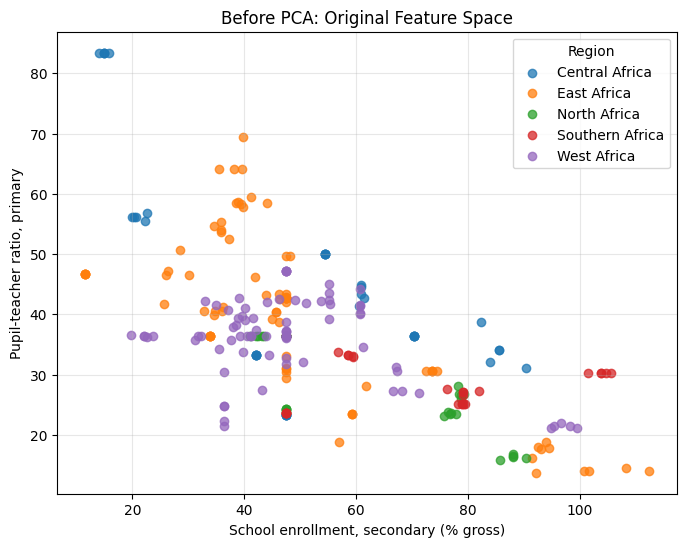

In [142]:
# Step 8a: Before PCA: two original indicators (secondary enrollment vs pupil-teacher ratio)
x_idx, y_idx = 3, 7
plt.figure(figsize=(8, 6))
for region in unique_regions:
    mask = regions == region
    plt.scatter(imputed_data[mask, x_idx], imputed_data[mask, y_idx], label=region, alpha=0.75)
plt.xlabel(short_names[x_idx]); plt.ylabel(short_names[y_idx])
plt.title("Before PCA: Original Feature Space")
plt.legend(title="Region"); plt.grid(True, alpha=0.3); plt.show()

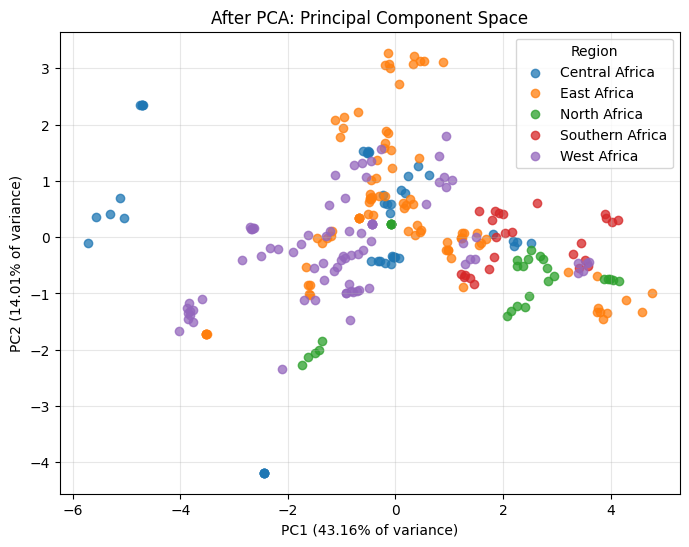

In [143]:
# Step 8b: After PCA: PC1 vs PC2
plt.figure(figsize=(8, 6))
for region in unique_regions:
    mask = regions == region
    plt.scatter(reduced_data[mask, 0], reduced_data[mask, 1], label=region, alpha=0.75)
plt.xlabel(f"PC1 ({explained_variance[0]:.2f}% of variance)")
plt.ylabel(f"PC2 ({explained_variance[1]:.2f}% of variance)")
plt.title("After PCA: Principal Component Space")
plt.legend(title="Region"); plt.grid(True, alpha=0.3); plt.show()

Please make sure you do not use more than 5 lines to answer each of the following points:

1. Interpret the Visual you just created of the before and after PCA
Before PCA, the plot shows only 2 of the 11 indicators: secondary enrollment and pupil-teacher ratio which are inversely related because as secondary enrollment increases, the pupil-teacher ratio decreases. North and Southern Africa have the highest secondary enrollment. After PCA, all 11 indicators are combined: PC1 (43.16%) acts as an overall education score, with North and Southern Africa mostly on the right (higher) and West and Central Africa mostly on the left (lower). PC2 (14.01%) shows high primary enrollment with crowded classes, where East African countries are the highest.
2. Explain why you selected the number of principle components, more especially explain what tradeoffs you are making
We reduced the 11 indicators to 6 principal components while keeping 90.44% of the information which makes the data simpler but we lost 9.56% of the information. Our tradeoff was to keep fewer components, which makes the data simpler instead of keeping all 11 which keeps all the information but leaves the data complicated. The eigenvalue > 1 rule would keep only 3 components (67.82%), but we chose 90% to keep more of the information.
3. Clearly mention based on your use case/ dataset ("economic activity”, “population pressure”), What information is lost when reducing dimensions?
We lost 9.56% of the information, held in PC7 to PC11. For example, PC11 holds the difference between adult and youth literacy, which tells us whether literacy is improving over generations. After dropping it, we can't easily see that anymore. But even though some information is lost, we can still see the bigger picture of which countries and regions are doing well and which have crowded primary schools.


Task 3: Benchmarking

In [144]:
# Create a large dataset by repeating the real data 500 times
import time
large_data = np.tile(standardized_data, (500, 1))
print("Large simulated dataset shape:", large_data.shape)

Large simulated dataset shape: (135000, 11)


In [145]:
# Time the full vectorized PCA pipeline on the large dataset
start = time.perf_counter()
large_cov = np.cov(large_data, rowvar=False)
large_vals, large_vecs = np.linalg.eigh(large_cov)
order = np.argsort(large_vals)[::-1]
large_reduced = large_data @ large_vecs[:, order][:, :num_components]
print(f"Vectorized PCA time: {time.perf_counter() - start:.4f} seconds")
print("Large reduced data shape:", large_reduced.shape)

Vectorized PCA time: 0.0261 seconds
Large reduced data shape: (135000, 6)


In [146]:
# Optimization choices used
print("1. Vectorized matrix operations (@) instead of Python loops.")
print("2. np.linalg.eigh for the symmetric covariance matrix.")
print("3. Dynamic selection of components using cumulative explained variance.")

1. Vectorized matrix operations (@) instead of Python loops.
2. np.linalg.eigh for the symmetric covariance matrix.
3. Dynamic selection of components using cumulative explained variance.
